#USA Real Estate Price Analysis & Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('realtor-data.zip.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115371 entries, 0 to 115370
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   brokered_by     115287 non-null  float64
 1   status          115371 non-null  object 
 2   price           115353 non-null  float64
 3   bed             97439 non-null   float64
 4   bath            98677 non-null   float64
 5   acre_lot        83933 non-null   float64
 6   street          114855 non-null  float64
 7   city            115348 non-null  object 
 8   state           115370 non-null  object 
 9   zip_code        115337 non-null  float64
 10  house_size      78264 non-null   float64
 11  prev_sold_date  60619 non-null   object 
dtypes: float64(8), object(4)
memory usage: 10.6+ MB


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,115287.000000,1.153530e+05,97439.000000,98677.000000,83933.000000,1.148550e+05,115337.000000,7.826400e+04
mean,50272.535394,9.081611e+05,3.310215,2.522097,17.612257,9.768200e+05,8299.399239,2.164912e+03
std,31527.856143,3.402015e+06,1.855004,1.727731,974.413505,5.632820e+05,4564.002495,5.819451e+03
min,32.000000,0.000000e+00,1.000000,1.000000,0.000000,4.000000e+00,601.000000,1.000000e+02
25%,22611.000000,2.500000e+05,2.000000,2.000000,0.110000,5.145825e+05,6032.000000,1.152000e+03
50%,48311.000000,4.499000e+05,3.000000,2.000000,0.270000,9.649350e+05,8015.000000,1.666000e+03
75%,78837.000000,8.000000e+05,4.000000,3.000000,1.060000,1.448616e+06,10308.000000,2.500000e+03
max,110138.000000,8.750000e+08,123.000000,198.000000,100000.000000,2.001355e+06,99999.000000,1.450112e+06


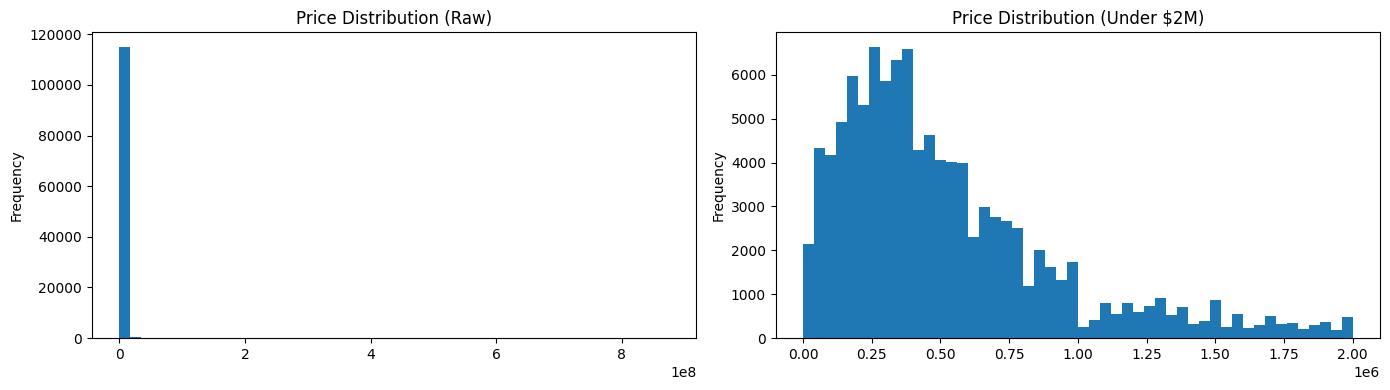

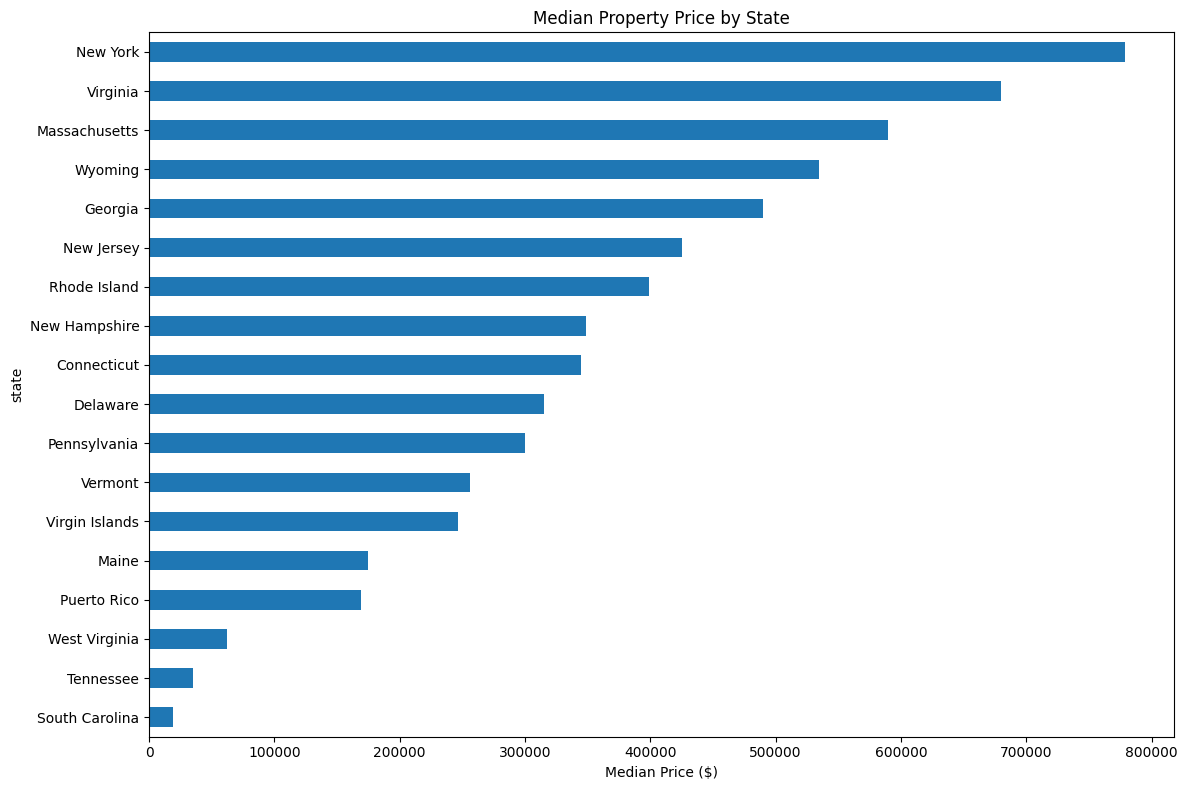

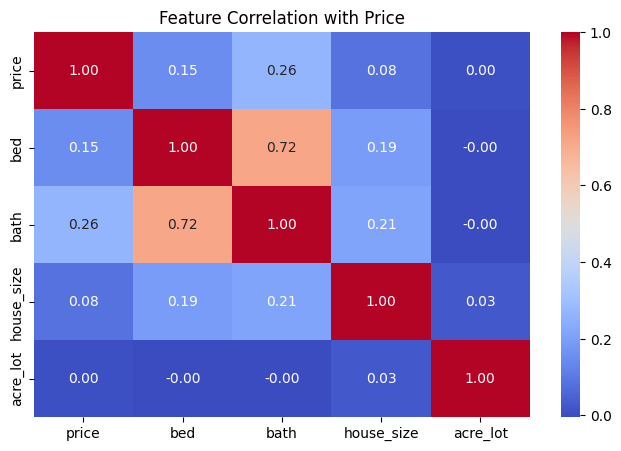

In [4]:
# Drop columns not useful for analysis
df = df.drop(columns=['brokered_by', 'street'])

# --- Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['price'].plot(kind='hist', bins=50, ax=axes[0], title='Price Distribution (Raw)')
df[df['price'] < 2_000_000]['price'].plot(kind='hist', bins=50, ax=axes[1],
                                           title='Price Distribution (Under $2M)')
plt.tight_layout()
plt.show()

# --- Average price by state ---
plt.figure(figsize=(12, 8))
df.groupby('state')['price'].median().sort_values().plot(kind='barh')
plt.title('Median Property Price by State')
plt.xlabel('Median Price ($)')
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
plt.figure(figsize=(8, 5))
sns.heatmap(df[['price','bed','bath','house_size','acre_lot']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Price')
plt.show()

From the state chart:

Massachusetts has the highest median price (~$600k)
South Carolina, Tennessee, West Virginia are the most affordable
Interesting that Wyoming ranks #2 — likely luxury/resort properties skewing it

From the correlation heatmap:

bath (0.26) and bed (0.15) have weak-moderate correlation with price
house_size only 0.08 — surprisingly low, likely because outliers are distorting it
acre_lot has basically zero correlation (0.00) — lot size doesn't drive price much
bed and bath are highly correlated with each other (0.72) — expected



In [5]:
# Remove rows where price is missing or zero
df = df[df['price'].notna() & (df['price'] > 0)]

# Remove extreme price outliers (keep under $3M for cleaner modeling)
df = df[df['price'] < 3_000_000]

# Remove unrealistic bed/bath values
df = df[(df['bed'] >= 1) & (df['bed'] <= 10)]
df = df[(df['bath'] >= 1) & (df['bath'] <= 10)]

# Fill missing house_size and acre_lot with median
df['house_size'] = df['house_size'].fillna(df['house_size'].median())
df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].median())

# Drop remaining nulls
df = df.dropna(subset=['bed', 'bath', 'state'])

print(f"Clean dataset: {df.shape[0]} rows remaining")

Clean dataset: 91063 rows remaining


## Data Cleaning Summary
- Removed rows with missing or zero prices
- Capped prices at $3M to remove extreme outliers
- Filtered beds/baths to realistic ranges (1–10)
- Filled missing house_size and acre_lot with median values
- Final dataset: 91,063 rows

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode the 'state' column as a number
le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['state'])

# Define features and target
X = df[['bed', 'bath', 'house_size', 'acre_lot', 'state_encoded']]
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {r2:.3f}")

RMSE: $381,806
R² Score: 0.494


## Model Results — Random Forest
- R² Score: 0.494 (model explains ~49% of price variance)
- RMSE: $381,806
- Baseline model using 5 features with no hyperparameter tuning

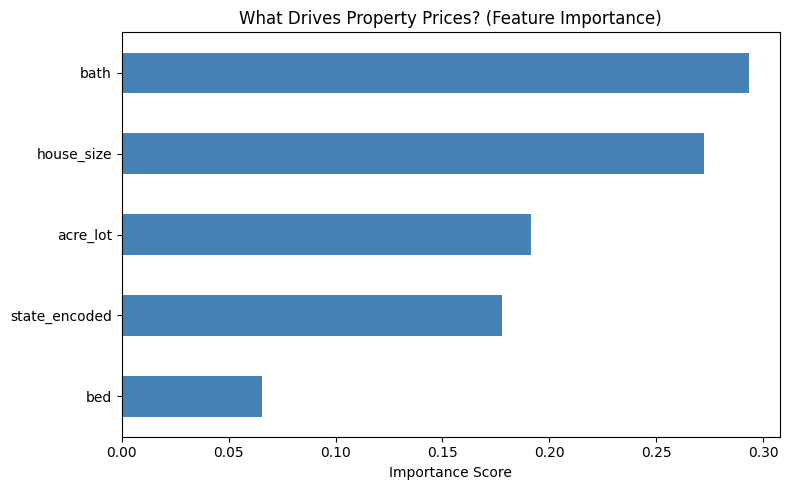

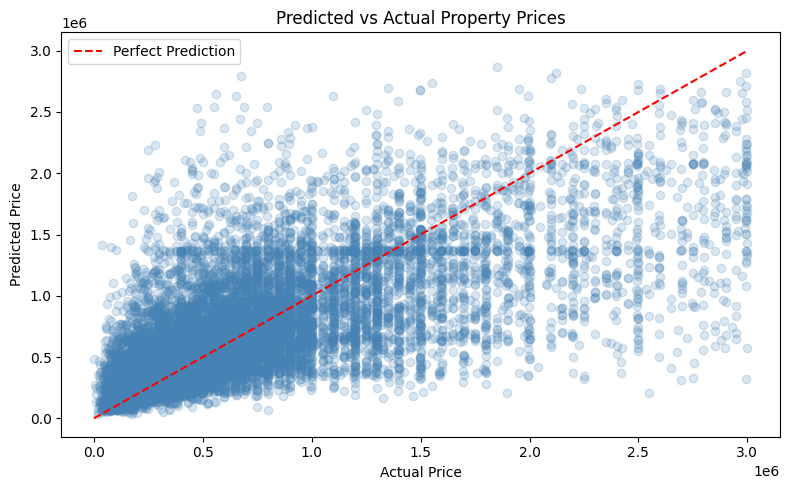

In [7]:
# Feature importance chart
feat_imp = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 5))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('What Drives Property Prices? (Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.2, color='steelblue')
plt.plot([0, 3_000_000], [0, 3_000_000], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Property Prices')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions & Key Findings

### What drives property prices?
- **Bath count** is the strongest predictor (0.29 importance)
- **House size** is close behind (0.27)
- **Acre lot** and **state** contribute similarly (~0.18–0.19)
- **Bed count** matters least (0.06) — likely because it overlaps with bath

### Model Performance
- R² of 0.494 — the model captures ~49% of price variance
- The predicted vs actual chart shows a positive trend but wide spread,
  suggesting location details (city/zip) would significantly improve accuracy

### Limitations & Next Steps
- Adding zip code or city as a feature could improve R² substantially
- XGBoost or tuning hyperparameters would likely improve performance
- A log transformation on price could reduce skew and improve RMSE